# Спектральная устойчивость стационарной итерации

Воспроизводимый вычислительный блокнот для экспериментов нового раздела 4.3.
Численные алгоритмы реализованы в пакете `em3d`; блокнот только задаёт конфигурацию,
запускает пакетные сценарии и показывает сохранённые таблицы и рисунки.

Экспериментальные блоки:

- **E0–E2B** — согласованность плотного и БПФ-операторов, перенос параметра и Arnoldi-диагностика;
- **E4** — геометрическое разрешение локальной неоднородности;
- **E6** — объёмное усреднение материального параметра;
- **E5** — ансамблевая спектральная локализация;
- **E3/E3b** — волновое разрешение и фазовая граница существования/устойчивости параметра.

Подробная классификация E3 различает достижение допуска, асимптотическое затухание без
достижения допуска, неустойчивость и неразрешённый режим. Трёхфазная карта статьи
сохраняется как отдельная явно обозначенная проекция.

## 1. Конфигурация и воспроизводимость

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").is_dir() and (REPO_ROOT.parent / "experiments").is_dir():
    REPO_ROOT = REPO_ROOT.parent
for candidate in (REPO_ROOT, REPO_ROOT / "src"):
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from experiments.em_spectral import (
    SpectralStudyConfig,
    run_spectral_experiment_suite,
)

KAGGLE_ROOT = Path("/kaggle/working")
OUTPUT_ROOT = (
    KAGGLE_ROOT / "em_spectral_chapter_experiments"
    if KAGGLE_ROOT.exists()
    else REPO_ROOT / "experiments" / "outputs" / "em_spectral_notebook"
)
OUTPUT_ROOT

PosixPath('/mnt/data/em3d_work/experiments/outputs/em_spectral_notebook')

In [2]:
MODE = "quick"          # заменить на "publication" для финальной серии
DEVICE = "auto"         # "cpu", "cuda" или "auto"
RUN_FINE = True
RUN_CORE_ARNOLDI = False
RUN_BOUNDARY_ARNOLDI = False
RENDER_FIGURES = True

factory = (
    SpectralStudyConfig.quick
    if MODE == "quick"
    else SpectralStudyConfig.publication
)
config = factory(output_root=OUTPUT_ROOT, device=DEVICE)
config

SpectralStudyConfig(mode='quick', grids=GridHierarchyConfig(coarse_sizes=(2, 3), control_size=4, fine_size=8), iteration=IterationStudyConfig(max_iter=120, rtol=1e-07, divergence_guard=1000000.0), arnoldi=ArnoldiConfig(krylov_dimension=20, milestones=(5, 10, 15, 20), seed=20260909, breakdown_tolerance=1e-13, reorthogonalization_passes=2, store_hessenberg=True), geometry=GeometryScanConfig(inclusion_sides=(0.25, 0.5), ensembles=((2, 3),)), wave_number=WaveNumberScanConfig(inclusion_side=0.5, wave_numbers=(0.5, 1.0), boundary_points=(), ppw_threshold=2.0, arnoldi_boundary_only=True), runtime=RuntimeConfig(device='auto', precision='double', random_seed=20260908), eigenvalue_repeats=1, output_root=PosixPath('/mnt/data/em3d_work/experiments/outputs/em_spectral_notebook'))

## 2. Полный пакетный запуск E0–E6

In [3]:
study = run_spectral_experiment_suite(
    config,
    include_core=True,
    include_geometry=True,
    include_volume_averaging=True,
    include_ensemble=True,
    include_wave_number=True,
    include_fine=RUN_FINE,
    include_core_arnoldi=RUN_CORE_ARNOLDI,
    include_boundary_arnoldi=RUN_BOUNDARY_ARNOLDI,
    render_figures=RENDER_FIGURES,
)
study.output_root

'/mnt/data/em3d_work/experiments/outputs/em_spectral_notebook'

In [4]:
def read_table(name: str) -> pd.DataFrame:
    return pd.read_csv(OUTPUT_ROOT / "tables" / name)

manifest = json.loads((OUTPUT_ROOT / "manifest.json").read_text(encoding="utf-8"))
{
    "status": manifest["status"],
    "git_commit": manifest["git_commit"],
    "em3d_version": manifest["em3d_version"],
    "artifact_count": len(manifest["artifacts"]),
}

{'status': 'complete',
 'git_commit': '2f0a79485874099de7f01fd54c0d02463164dae7',
 'em3d_version': '0.4.0',
 'artifact_count': 141}

## 3. E0–E2B: базовый перенос спектрального параметра

In [5]:
display(read_table("operator_consistency.csv"))
display(read_table("control_transfers.csv"))
if (OUTPUT_ROOT / "tables" / "fine_transfers.csv").is_file():
    display(read_table("fine_transfers.csv"))

,case,N,relative_dense_fft_error,seed
0,homogeneous_anisotropic,2,2.038380e-16,20260908
1,anisotropic_ellipsoid,2,0.000000e+00,20260908
2,local_inclusion,2,1.541269e-16,20260908


,case,N_H,N_c,parameter_exists,coarse_status,epsilon_directed,epsilon_hausdorff,q_H,Delta_H,eta,q_c_mu_H,q_bound_c,certified
0,homogeneous_anisotropic,2,4,True,ok,0.235275,0.346958,0.557367,0.663274,0.354718,0.643272,0.714377,True
1,homogeneous_anisotropic,3,4,True,ok,0.051960,0.092211,0.520987,0.698936,0.074341,0.554848,0.556597,True
2,anisotropic_ellipsoid,2,4,False,degenerate_spectrum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,anisotropic_ellipsoid,3,4,True,ok,0.457394,0.457394,0.142857,1.000000,0.457394,0.534540,0.534909,True
4,local_inclusion,2,4,True,ok,0.141942,0.208088,0.387017,0.791641,0.179301,0.449762,0.496925,True
5,local_inclusion,3,4,True,ok,0.031967,0.315159,0.432628,0.812434,0.039347,0.453328,0.454953,True


,case,parameter,mu_real,mu_imag,q_H,converged,status,iterations,matvec_count,final_residual,minimum_residual,minimum_residual_iteration,asymptotic_ratio,classification,observations_used,elapsed_seconds
0,homogeneous_anisotropic,N2,1.494908,-0.103289,0.557367,True,converged,35,36,8.849845e-08,8.849845e-08,35,0.630779,converged,20,0.017928
1,homogeneous_anisotropic,N3,1.428126,-0.299126,0.520987,True,converged,27,28,6.079575e-08,6.079575e-08,27,0.541858,converged,16,0.033545
2,homogeneous_anisotropic,N4,1.416534,-0.341482,0.536716,True,converged,25,26,9.309743e-08,9.309743e-08,25,0.524052,converged,15,0.013558
3,anisotropic_ellipsoid,N3,1.166667,0.000000,0.142857,True,converged,18,19,7.484009e-08,7.484009e-08,18,0.497706,converged,10,0.009976
4,anisotropic_ellipsoid,N4,1.389517,0.018865,0.287896,True,converged,13,14,9.248976e-08,9.248976e-08,13,0.284101,converged,8,0.007345
5,local_inclusion,N2,1.289615,-0.068947,0.387017,True,converged,20,21,9.336913e-08,9.336913e-08,20,0.443718,converged,12,0.011272
6,local_inclusion,N3,1.420353,-0.181679,0.432628,True,converged,20,21,7.649617e-08,7.649617e-08,20,0.440173,converged,12,0.011009
7,local_inclusion,N4,1.249390,-0.216995,0.375650,True,converged,24,25,8.727362e-08,8.727362e-08,24,0.566989,converged,14,0.011754


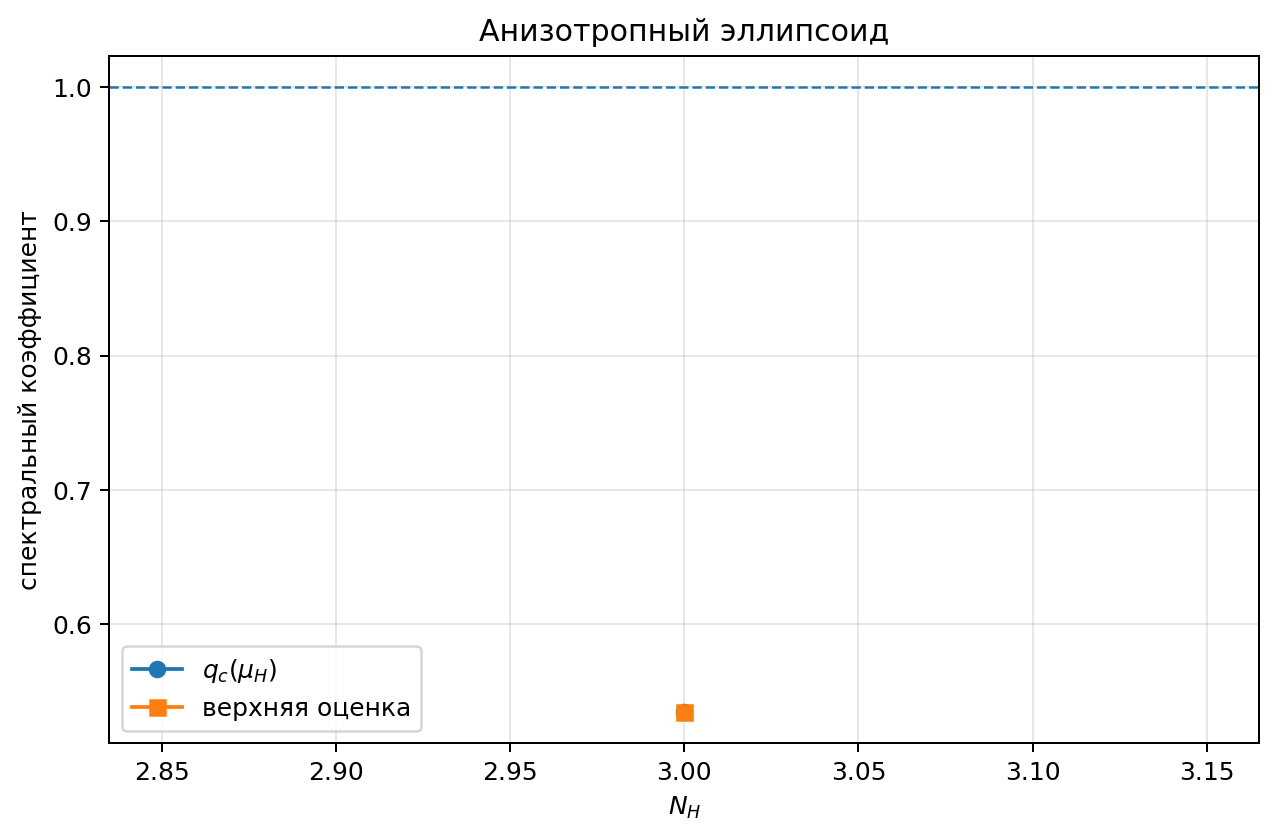

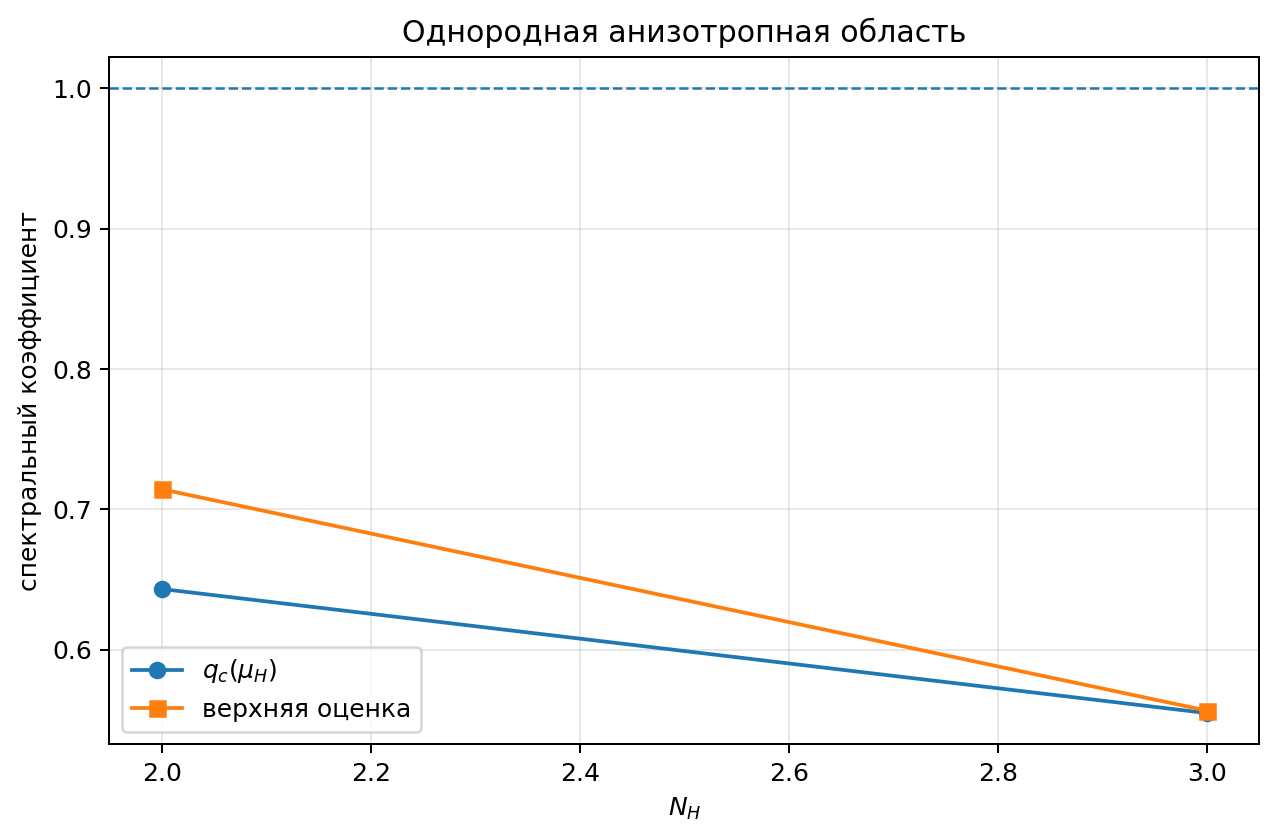

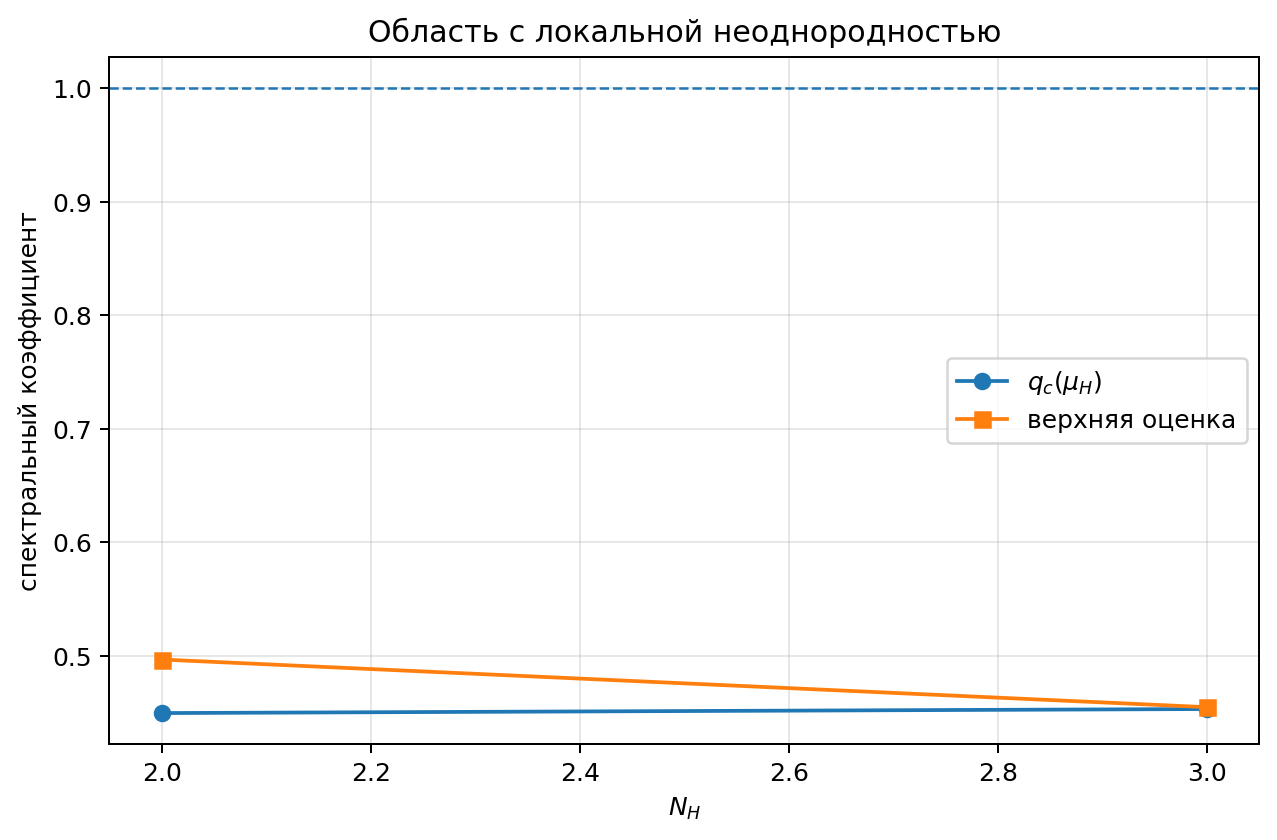

In [6]:
for path in sorted((OUTPUT_ROOT / "figures" / "core").glob("*_control_transfer.png")):
    display(Image(filename=str(path)))

## 4. E4: геометрическое разрешение локального включения

In [7]:
e4 = read_table("E4_summary.csv")
display(e4[[
    "inclusion_side", "N_H", "coarse_cells_min_axis",
    "q_H", "eta", "q_c_mu_H", "certified_control",
    "fine_classification", "observed_residual_ratio",
]])

,inclusion_side,N_H,coarse_cells_min_axis,q_H,eta,q_c_mu_H,certified_control,fine_classification,observed_residual_ratio
0,0.25,2,0,0.387017,1.372165,1.081384,False,converged,0.443718
1,0.25,3,1,0.432628,0.886295,0.899199,True,converged,0.440173
2,0.25,4,2,0.569461,0.000000,0.569461,True,converged,0.536713
3,0.50,2,2,0.845959,0.000000,0.626156,True,converged,0.626859
4,0.50,3,1,0.432628,0.886295,0.899199,True,unstable,1.019888
5,0.50,4,2,0.569461,0.000000,0.569461,True,converged,0.574644


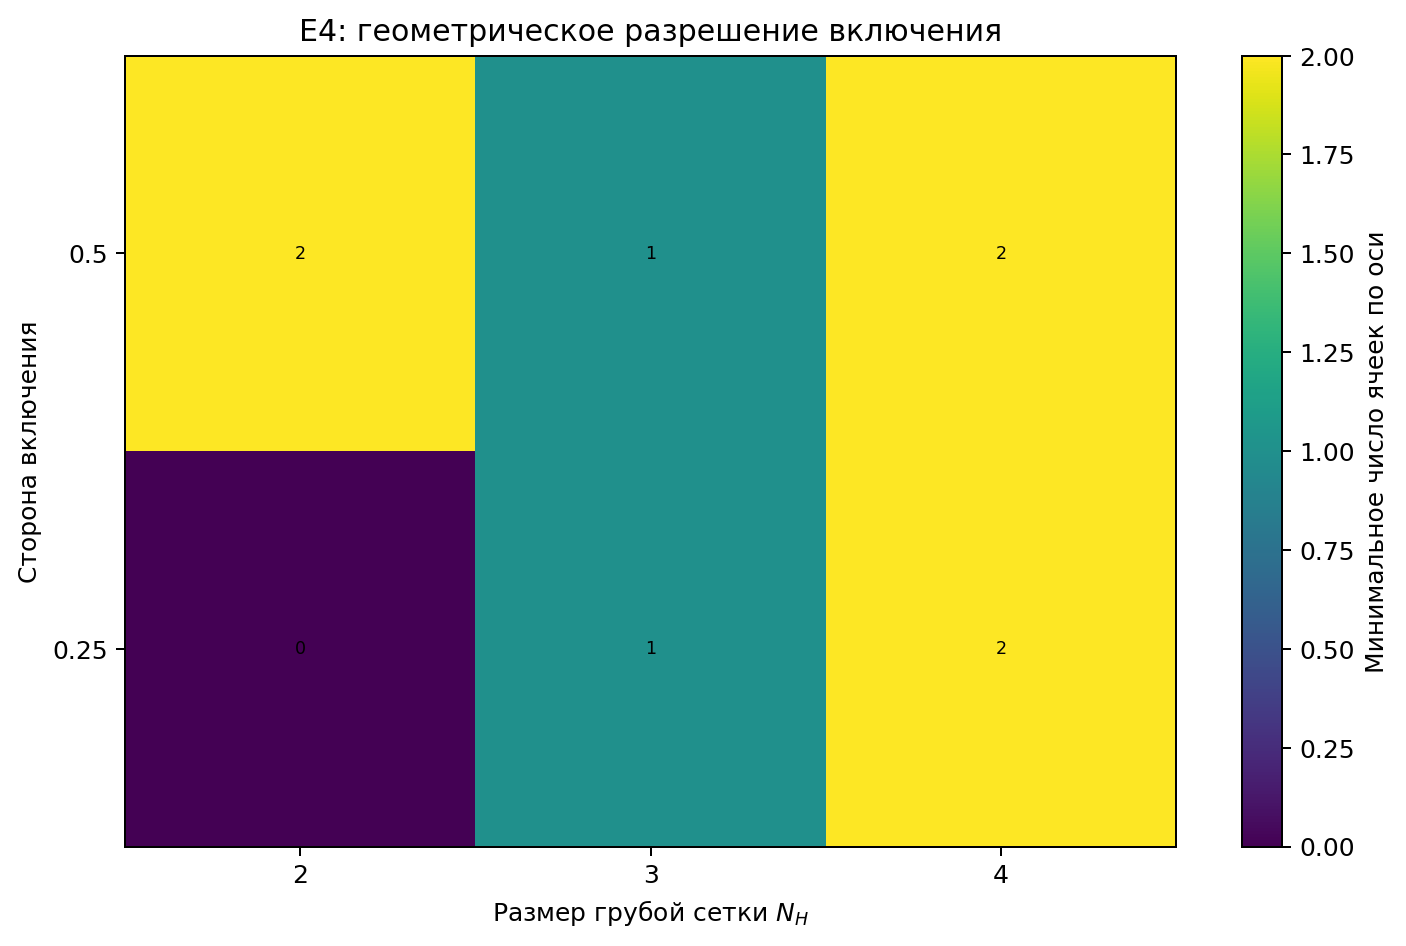

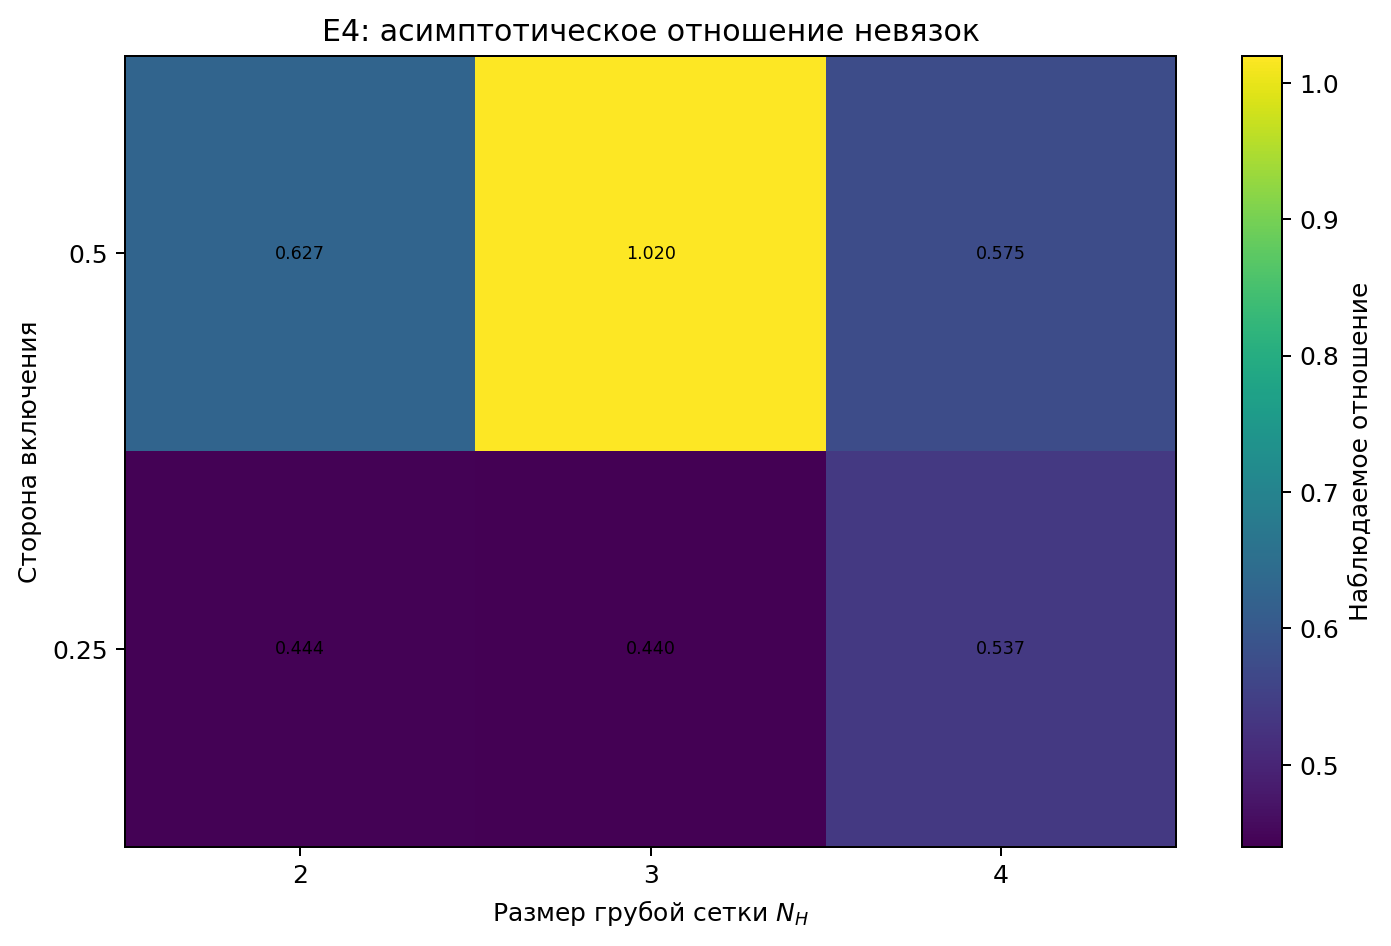

In [8]:
display(Image(filename=str(OUTPUT_ROOT / "figures" / "E4_geometry_cells.png")))
display(Image(filename=str(OUTPUT_ROOT / "figures" / "E4_geometry_ratio.png")))

## 5. E6: объёмное усреднение

In [9]:
e6 = read_table("E6_comparison.csv")
display(e6[[
    "inclusion_side", "N_H", "avg_volume_rel_error",
    "center_classification", "avg_classification",
    "center_ratio", "avg_ratio", "ratio_improvement",
    "recovered", "degraded",
]])

,inclusion_side,N_H,avg_volume_rel_error,center_classification,avg_classification,center_ratio,avg_ratio,ratio_improvement,recovered,degraded
0,0.25,2,0.0,converged,converged,0.443718,0.442022,0.001696,False,False
1,0.25,3,0.0,converged,converged,0.440173,0.424433,0.015740,False,False
2,0.25,4,0.0,converged,converged,0.536713,0.477548,0.059165,False,False
3,0.50,2,0.0,converged,unstable,0.626859,1.088066,-0.461206,False,True
4,0.50,3,0.0,unstable,converged,1.019888,0.897453,0.122436,True,False
5,0.50,4,0.0,converged,converged,0.574644,0.574644,0.000000,False,False


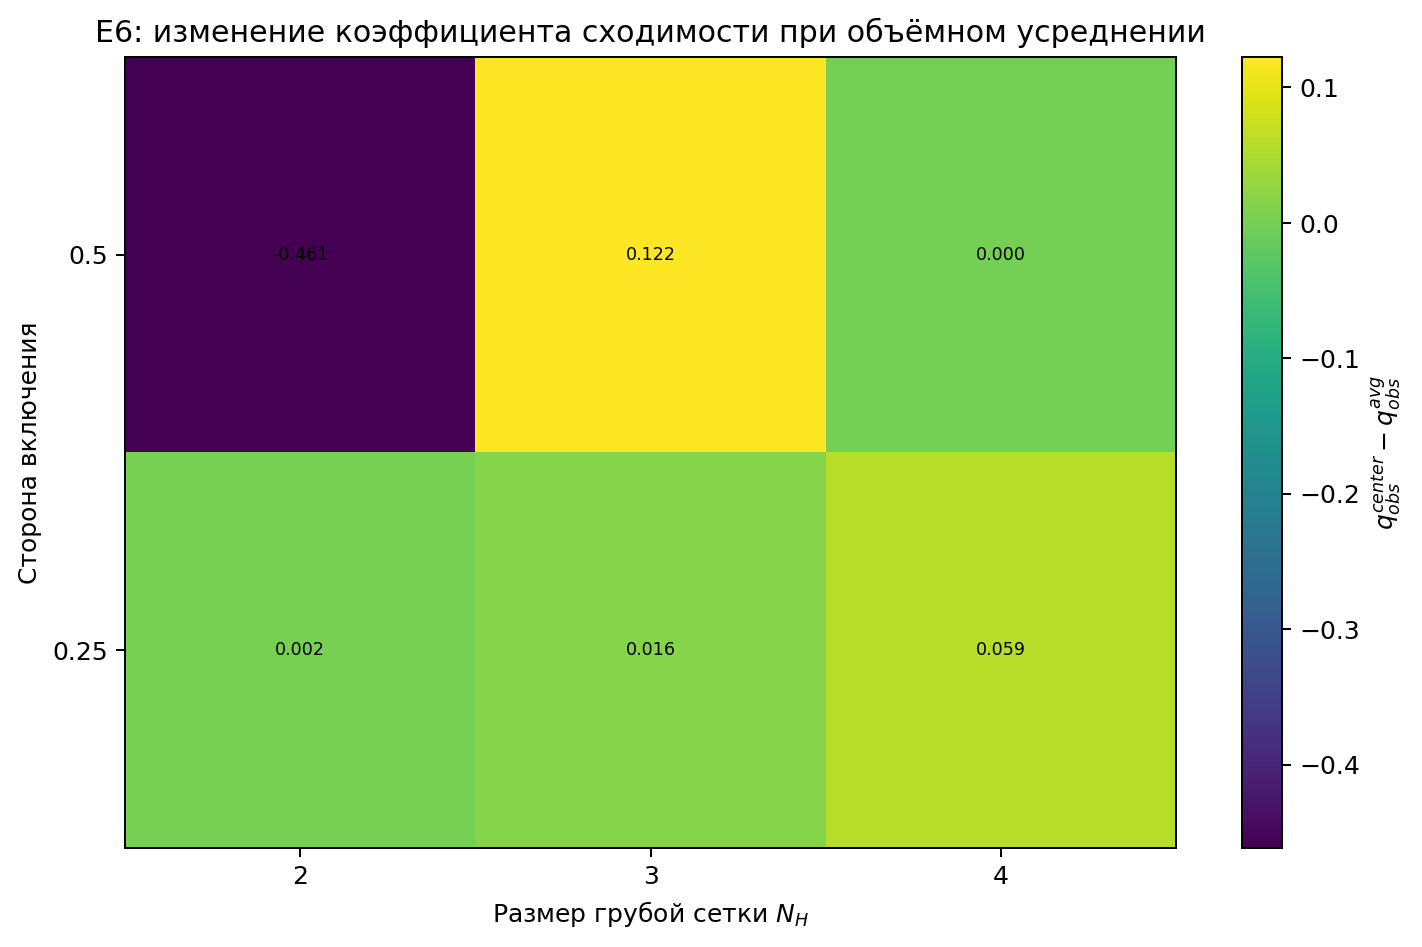

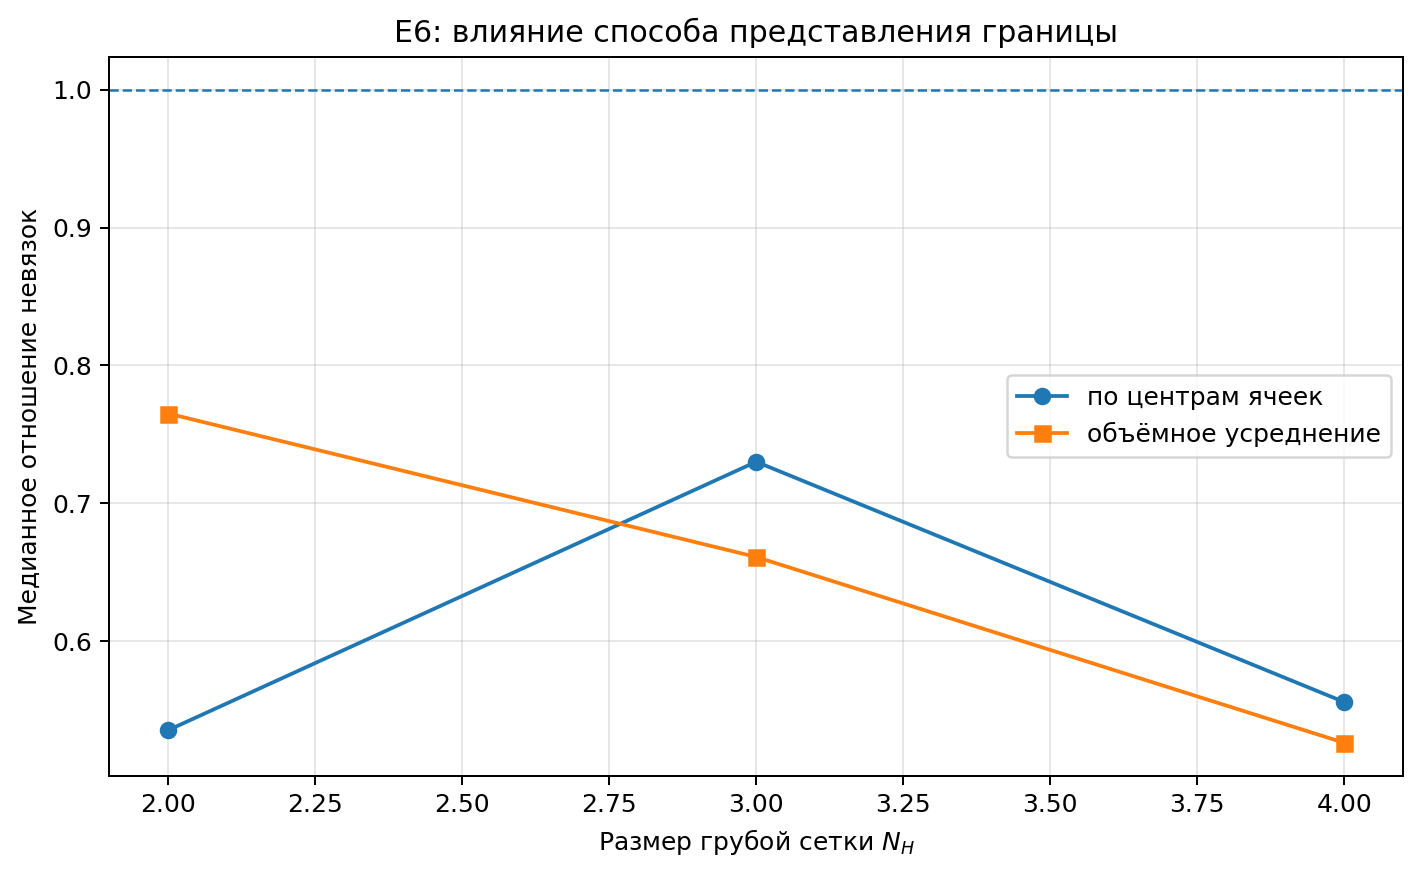

In [10]:
display(Image(filename=str(OUTPUT_ROOT / "figures" / "E6_volume_averaging_improvement.png")))
display(Image(filename=str(OUTPUT_ROOT / "figures" / "E6_volume_averaging_ratios.png")))

## 6. E5: ансамблевая локализация

In [11]:
e5 = read_table("E5_comparison.csv")
display(e5[[
    "inclusion_side", "ensemble", "maximum_resolution",
    "q_ensemble", "q_inflated_max", "certified_control",
    "ensemble_classification", "ensemble_ratio",
    "recovered_asymptotic", "degraded_asymptotic",
]])

,inclusion_side,ensemble,maximum_resolution,q_ensemble,q_inflated_max,certified_control,ensemble_classification,ensemble_ratio,recovered_asymptotic,degraded_asymptotic
0,0.25,2+3,1,0.440207,0.715562,True,converged,0.449557,False,False
1,0.50,2+3,2,0.845959,1.764417,True,converged,0.626859,True,False


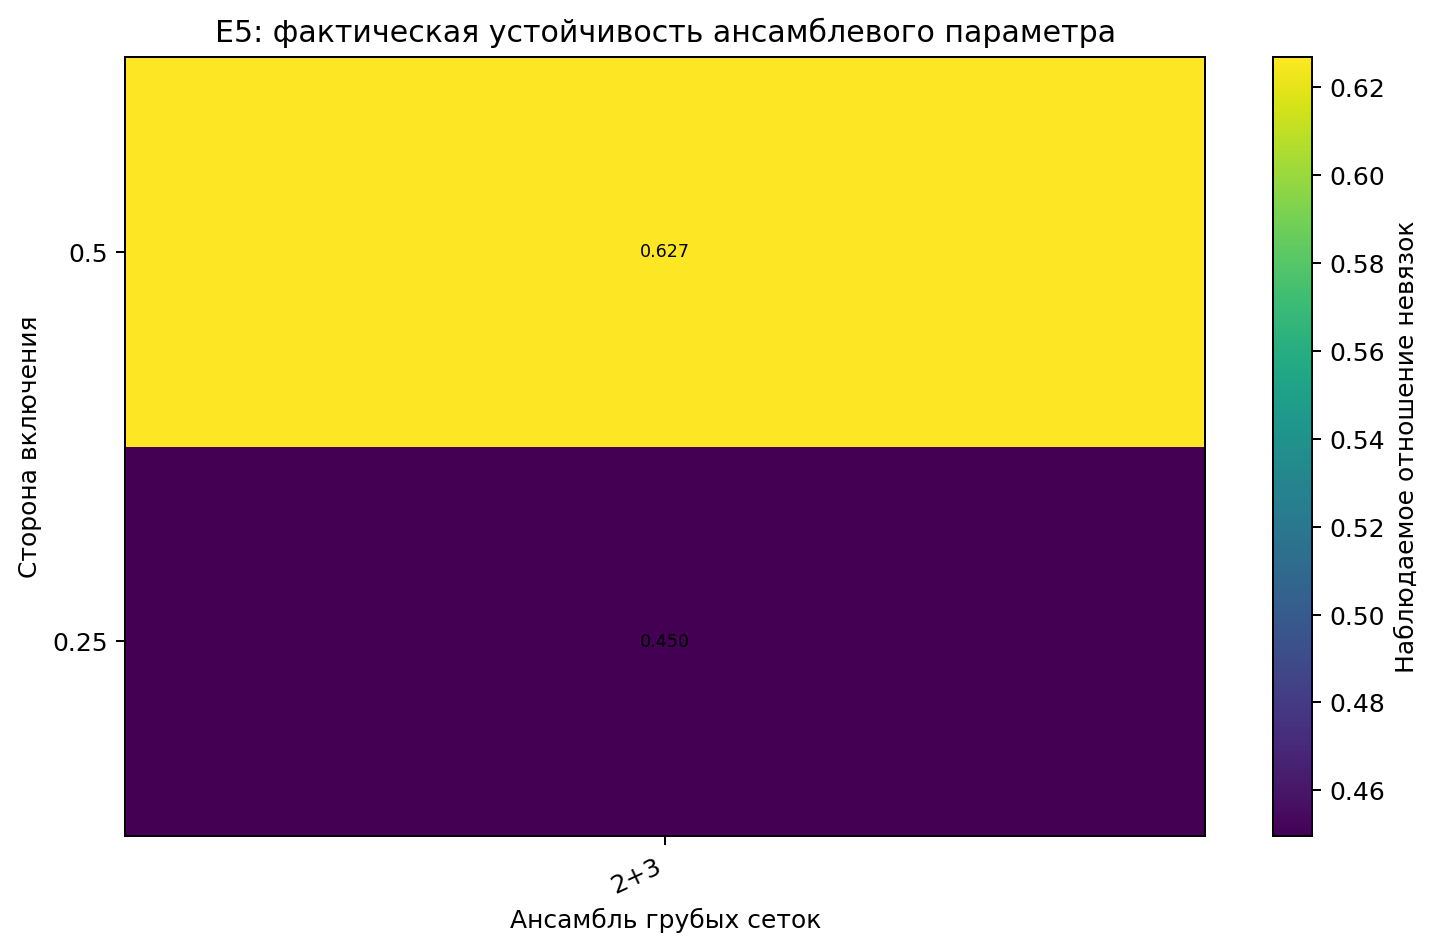

In [12]:
display(Image(filename=str(OUTPUT_ROOT / "figures" / "E5_ensemble_ratio.png")))

## 7. E3/E3b: волновая фазовая карта

In [13]:
e3 = read_table("E3_summary_phase.csv")
display(e3[[
    "k0", "N_H", "coarse_ppw_material", "origin_in_hull",
    "parameter_exists", "q_H", "q_c_mu_H",
    "phase_detailed", "reached_rtol", "observed_residual_ratio",
    "article_phase_code", "article_phase_basis",
]])
display(read_table("E3_by_k0_phase.csv"))
display(read_table("E3_sampling_rule_diagnostics.csv"))

,k0,N_H,coarse_ppw_material,origin_in_hull,parameter_exists,q_H,q_c_mu_H,phase_detailed,reached_rtol,observed_residual_ratio,article_phase_code,article_phase_basis
0,0.5,2,14.510032,False,True,0.404329,0.450047,converged,True,0.605069,2,solver_converged_or_contracting
1,0.5,3,21.765048,False,True,0.306153,0.749216,contracting_unresolved,False,0.959579,2,solver_converged_or_contracting
2,0.5,4,29.020064,False,True,0.445330,0.445330,converged,True,0.619056,2,solver_converged_or_contracting
3,1.0,2,7.255016,False,True,0.409120,0.454815,converged,True,0.584102,2,solver_converged_or_contracting
4,1.0,3,10.882524,False,True,0.307205,0.750573,contracting_unresolved,False,0.955611,2,solver_converged_or_contracting
5,1.0,4,14.510032,False,True,0.446295,0.446295,converged,True,0.615180,2,solver_converged_or_contracting


,experiment,k0,min_N_parameter_exists,min_N_contracting,min_N_reached_rtol,ppw_free_at_parameter,ppw_material_at_parameter,ppw_free_at_contracting,ppw_material_at_contracting,N_nyquist_free,N_nyquist_material,no_parameter_count,unstable_count,contracting_unresolved_count,unresolved_count,converged_count,fine_ppw_free,fine_ppw_material
0,E3,0.5,2,2,2,25.132741,14.510032,25.132741,14.510032,1,1,0,0,1,0,2,100.530965,58.040129
1,E3,1.0,2,2,2,12.566371,7.255016,12.566371,7.255016,1,1,0,0,1,0,2,50.265482,29.020064


,experiment,rule,TP,TN,FP,FN,accuracy,experiments
0,E3,combined_free_rule,4,0,0,2,0.666667,6
1,E3,combined_material_rule,4,0,0,2,0.666667,6


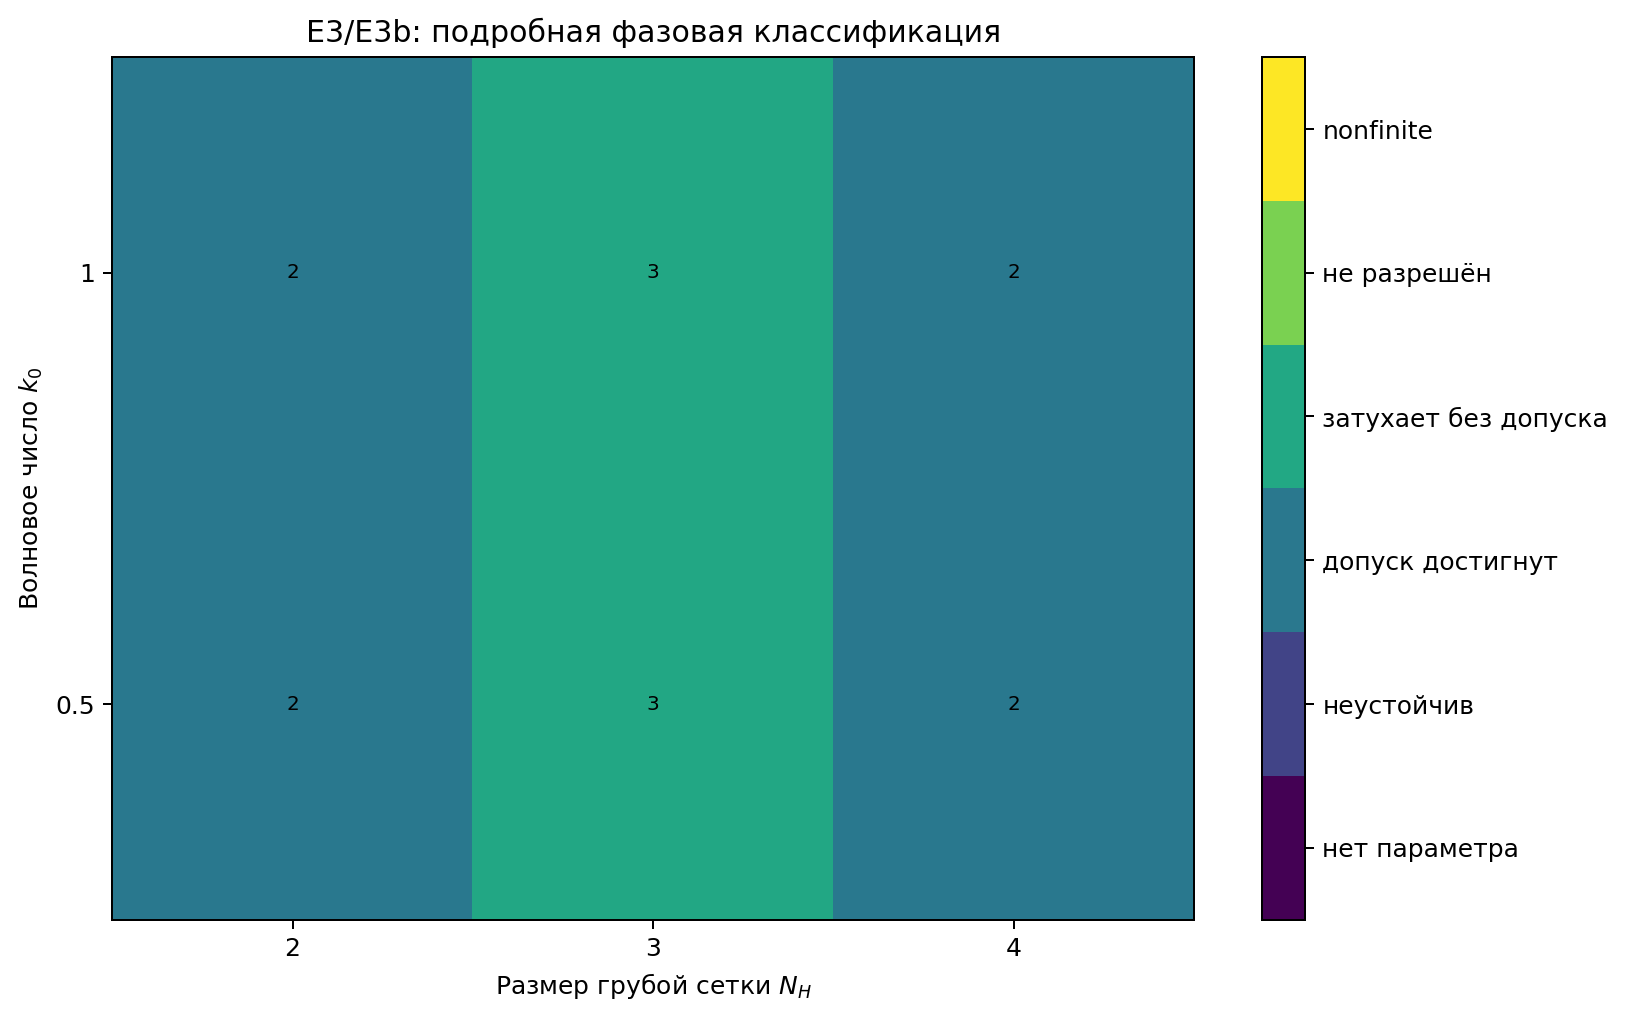

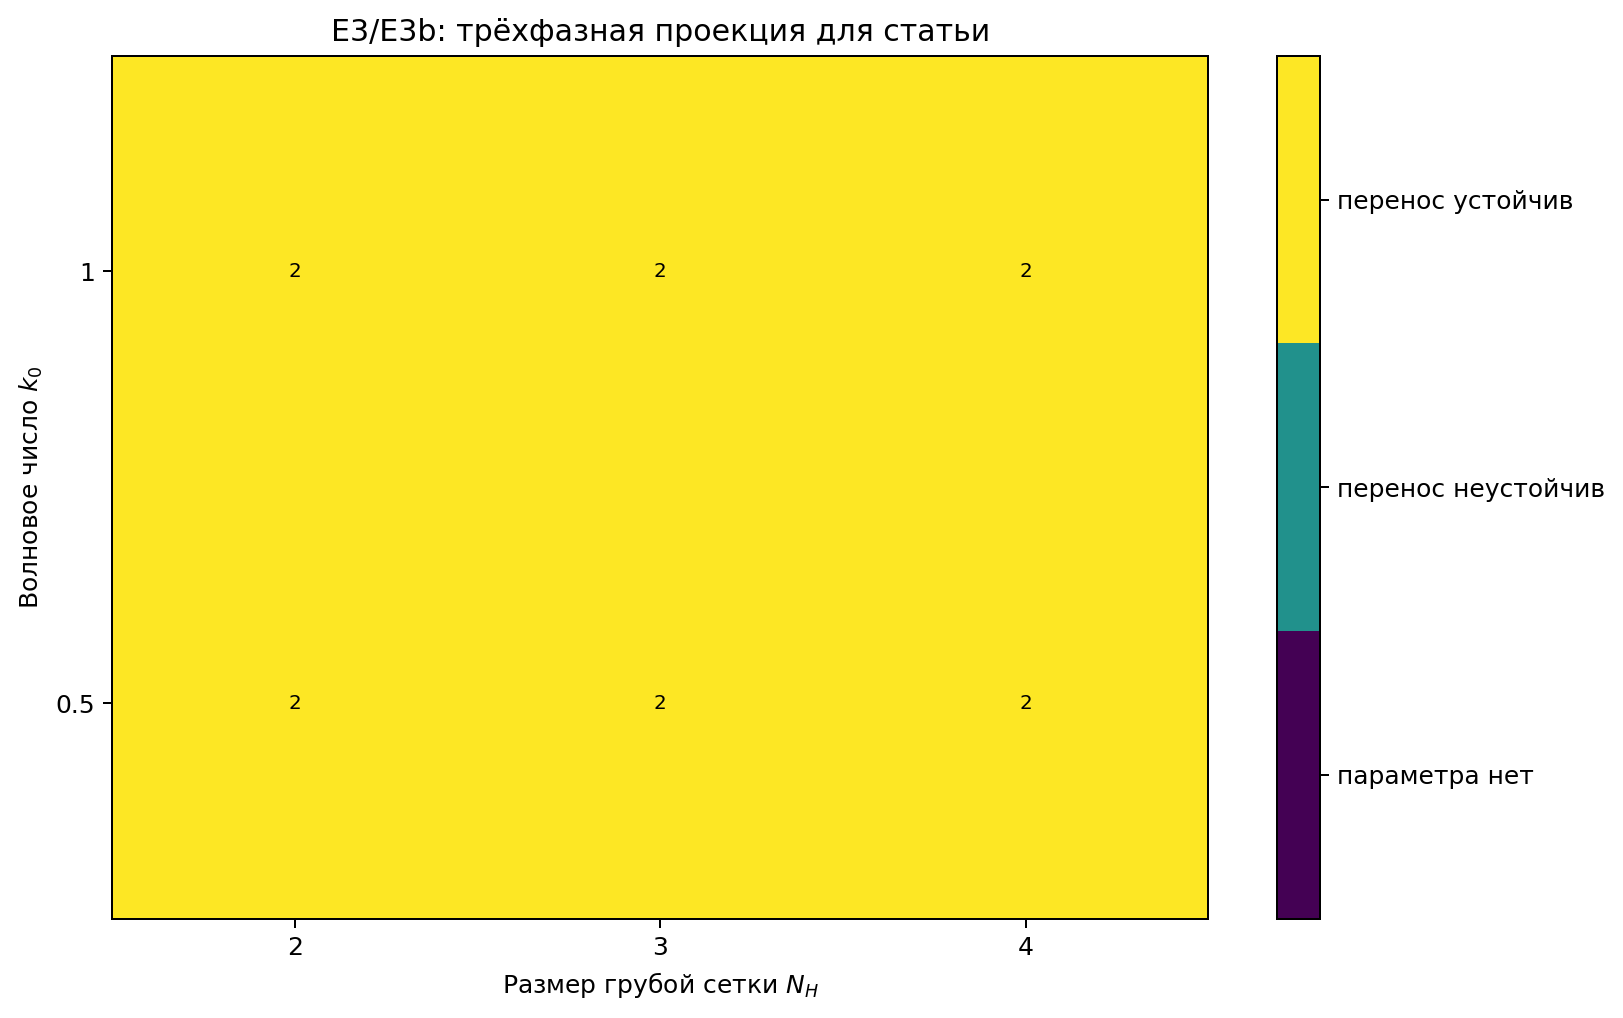

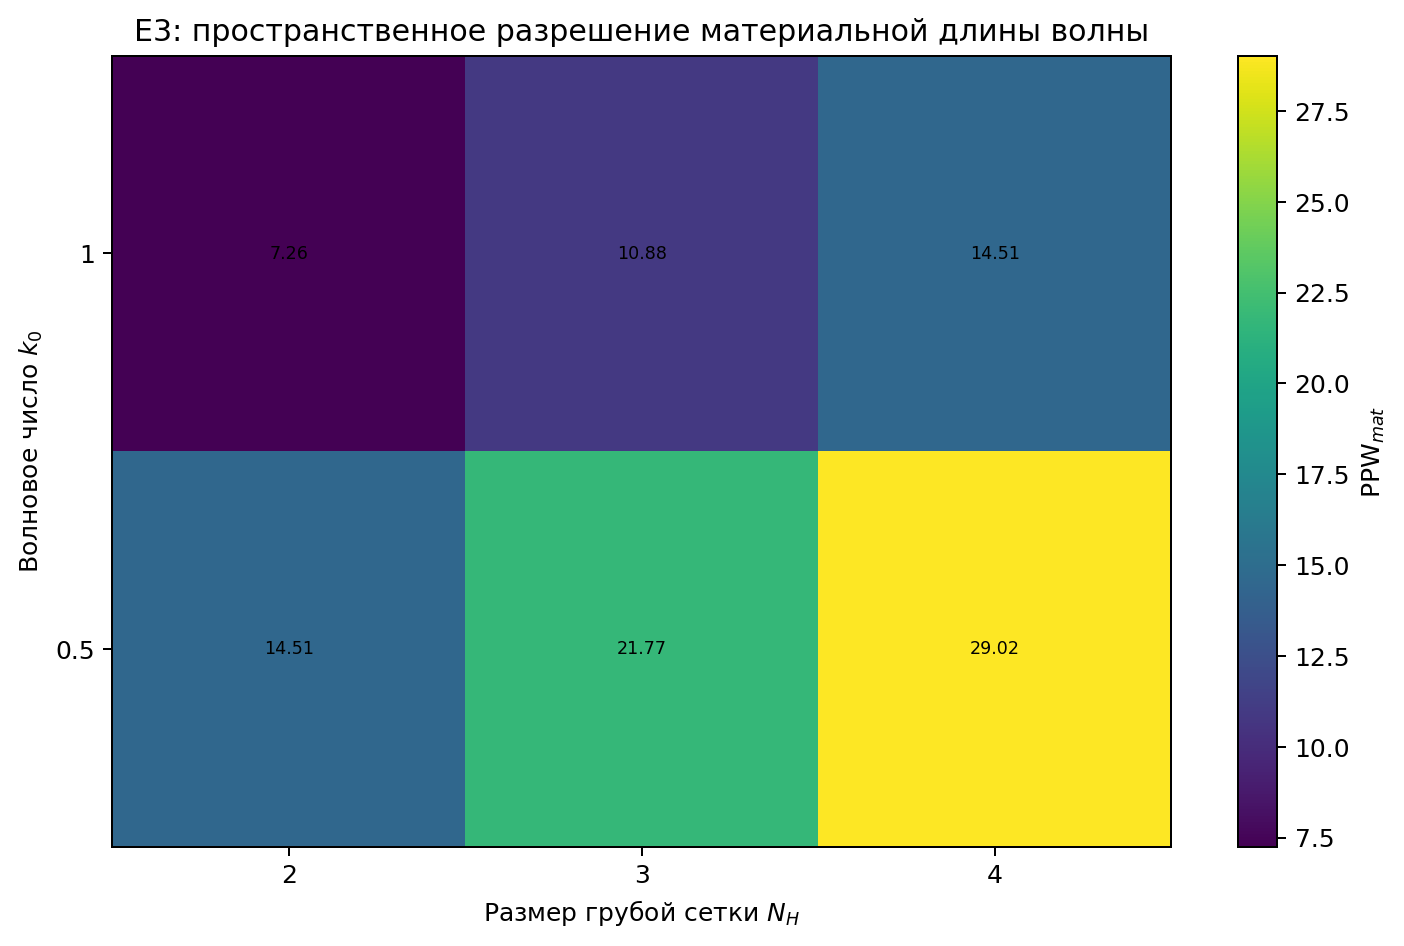

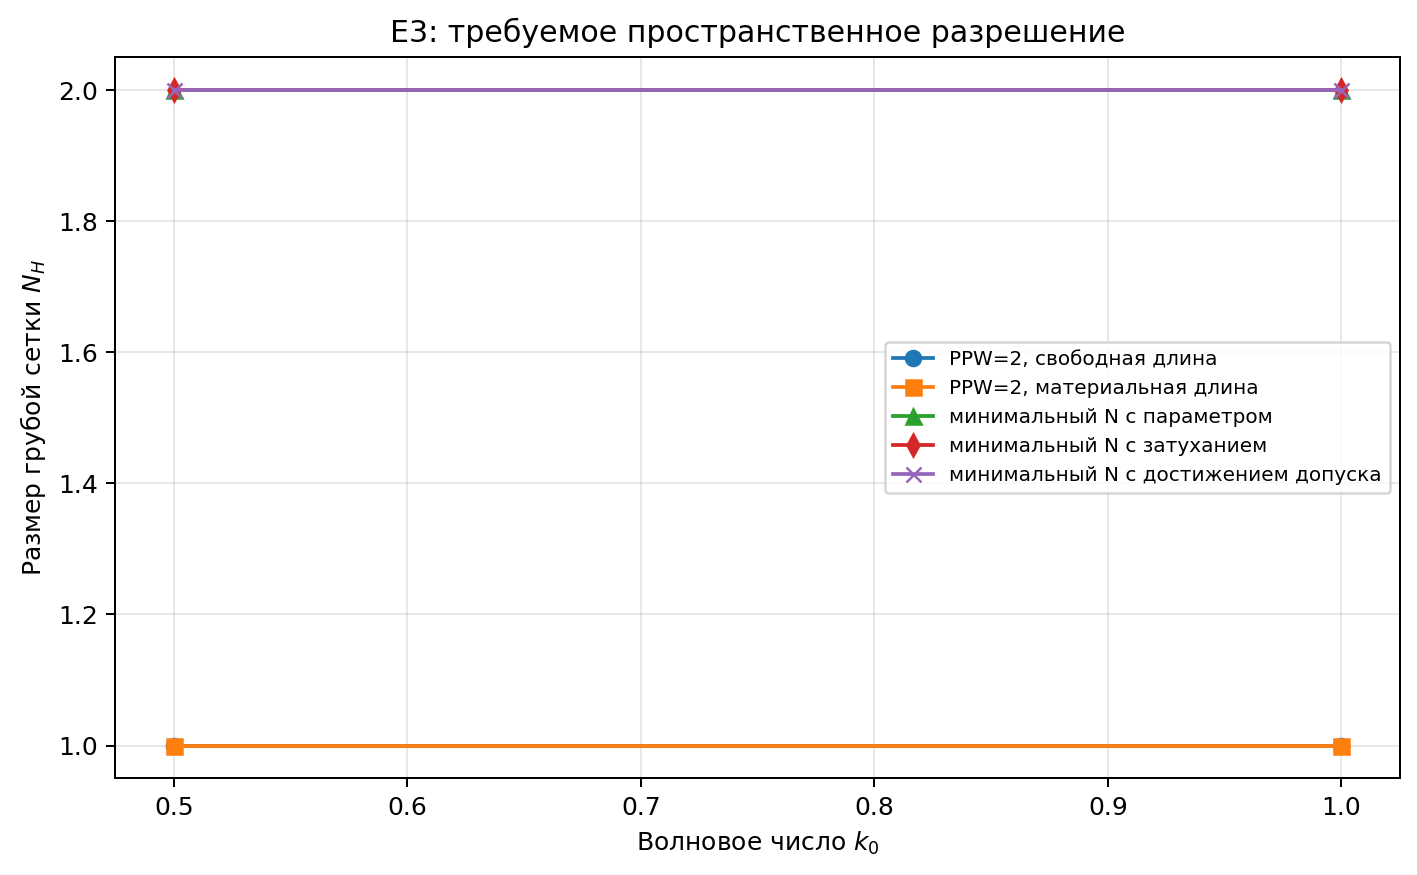

In [14]:
display(Image(filename=str(OUTPUT_ROOT / "figures" / "E3_phase_detailed.png")))
display(Image(filename=str(OUTPUT_ROOT / "figures" / "E3_phase_article.png")))
display(Image(filename=str(OUTPUT_ROOT / "figures" / "E3_material_ppw.png")))
display(Image(filename=str(OUTPUT_ROOT / "figures" / "E3_required_grid.png")))

## 8. Интерпретационные ограничения

1. Условие \(\varepsilon_{f,H}<\Delta_H\) является достаточным сертификатом, а его
   невыполнение само по себе не доказывает расходимость.
2. Режим `contracting_unresolved` означает наблюдаемое асимптотическое затухание, но
   заданный допуск за отведённое число итераций не достигнут.
3. Правило двух ячеек и критерий PPW являются эмпирическими индикаторами исследованной
   серии, а не универсальными теоремами.
4. Объёмное усреднение точно воспроизводит объём прямоугольного включения, но это не
   гарантирует воспроизведение его спектрального влияния.
5. Arnoldi-оценка является матрично-свободной диагностикой критической части спектра,
   а не вычислением полного спектра рабочей матрицы.

## 9. Состав сохранённых артефактов

In [15]:
artifacts = pd.DataFrame(manifest["artifacts"])
display(artifacts.groupby("kind").size().rename("count").to_frame())
display(artifacts.head(20))

,count
kind,
csv,29
json,29
npz,29
pdf,18
png,18
svg,18


,path,kind,sha256,bytes
0,config.json,json,7198a703d379571f5d1aac39e5ac4b467547e3a3ea925c...,988
1,raw/spectra/homogeneous_anisotropic_N2.npz,npz,48e51c77c1b993f647e8bdcd174e94e0946cca941626f6...,2060
2,raw/spectra/homogeneous_anisotropic_N3.npz,npz,2b20aad854b0a992504bd2a8b64d4c98ae364edd305153...,3022
3,raw/spectra/homogeneous_anisotropic_N4.npz,npz,63aba0a0a6eff2138bd0730375a6e817ed3bffdb230ba8...,4751
4,raw/residual_histories/homogeneous_anisotropic...,json,b6bd8d1df5bb653b705779f6dde57ffd5bd82f39b6b278...,874
5,raw/residual_histories/homogeneous_anisotropic...,json,b75e16a628afdae4ad9d143ee53a3735799c44d00288eb...,675
6,raw/residual_histories/homogeneous_anisotropic...,json,b024bc0814b2552568774970b21e3e585a825e97d976b5...,621
7,raw/spectra/anisotropic_ellipsoid_N2.npz,npz,a1b6a5e593909da493d3552e5f3b40d55187ebc91091f7...,1566
8,raw/spectra/anisotropic_ellipsoid_N3.npz,npz,a7aceacc106680454a5f8a785405d147ed2cefea418b6e...,1599
9,raw/spectra/anisotropic_ellipsoid_N4.npz,npz,bda968adfcef80e993a4c9793ac67a5a7ba9f7a8f0a9b6...,2149
